In [1]:
import pathlib
from datetime import datetime

import numpy as np
import pandas as pd
import xarray as xr

import scipy.ndimage as ndi

In [2]:
stats_path = pathlib.Path("/gws/ssde/j25a/esaclim/will")
stats_file = list(stats_path.glob("*_S20240810*"))[0]
stats_ds = xr.open_dataset(stats_file)

/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'cfradial1' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'datamet' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'furuno' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'gamic' loading failed:
No module named 'xarray.core.merge'
 

In [3]:
stats_ds

<xarray.Dataset> Size: 245MB
Dimensions:                                      (anvil: 58592,
                                                  thick_anvil_step: 1151260,
                                                  core_step: 950514,
                                                  thin_anvil_step: 1249512,
                                                  core: 212782)
Coordinates:
  * anvil                                        (anvil) int32 234kB 12 ... 9...
  * core_step                                    (core_step) int32 4MB 6 ... ...
  * thick_anvil_step                             (thick_anvil_step) int32 5MB ...
  * thin_anvil_step                              (thin_anvil_step) int32 5MB ...
  * core                                         (core) int32 851kB 119 ... 2...
    y_image                                      int64 8B ...
    x_image                                      int64 8B ...
Data variables: (12/144)
    thin_anvil_end_label_flag                    (anvil) bool 59kB ...
    thick_anvil_step_t                           (thick_anvil_step) datetime64[ns] 9MB ...
    core_step_core_index                         (core_step) int32 4MB ...
    thick_anvil_step_bt_std                      (thick_anvil_step) float32 5MB ...
    thin_anvil_step_anvil_index                  (thin_anvil_step) int32 5MB ...
    core_end_label_flag                          (core) bool 213kB ...
    ...                                           ...
    anvil_no_growth_flag                         (anvil) bool 59kB ...
    anvil_no_initial_core_flag                   (anvil) bool 59kB ...
    core_is_valid                                (core) bool 213kB ...
    anvil_invalid_core_flag                      (anvil) bool 59kB ...
    thick_anvil_is_valid                         (anvil) bool 59kB ...
    thin_anvil_is_valid                          (anvil) bool 59kB ...

In [4]:
overpass_path = pathlib.Path("/work/scratch-nopw2/wkjones/ec_track_overpasses")
overpass_files = sorted(list(overpass_path.glob("*.nc")))

In [5]:
overpass_dt = xr.open_datatree(overpass_files[0])

In [6]:
overpass_dt

<xarray.DataTree>
Group: /
│   Dimensions:            (along_track: 8465, height: 200)
│   Coordinates:
│       time               (along_track) datetime64[ns] 68kB ...
│       latitude           (along_track) float64 68kB ...
│       longitude          (along_track) float64 68kB ...
│     * height             (height) float64 2kB 1.995e+04 1.985e+04 ... 150.0 50.0
│   Dimensions without coordinates: along_track
│   Data variables:
│       core_label         (along_track) int32 34kB ...
│       thick_anvil_label  (along_track) int32 34kB ...
│       thin_anvil_label   (along_track) int32 34kB ...
│   Attributes:
│       granules:              01136H 01137A 01137B
│       track_mask_filenames:  detected_dccs_MSG_S20240810_000000_E20240811_00000...
├── Group: /CPR_CD__2A
│       Dimensions:                                                (along_track: 8465,
│                                                                   height: 200)
│       Coordinates:
│           time                                                   (along_track) datetime64[ns] 68kB ...
│           latitude                                               (along_track) float64 68kB ...
│           longitude                                              (along_track) float64 68kB ...
│       Dimensions without coordinates: along_track
│       Data variables:
│           quality_status                                         (along_track, height) float32 7MB ...
│           doppler_velocity_and_spectrum_width_integrated_error   (along_track, height) float32 7MB ...
│           doppler_velocity_and_spectrum_width_integrated_status  (along_track, height) float32 7MB ...
│           doppler_velocity_best_estimate                         (along_track, height) float32 7MB ...
│           sedimentation_velocity_best_estimate                   (along_track, height) float32 7MB ...
│           sedimentation_velocity_best_estimate_error             (along_track, height) float32 7MB ...
│           sedimentation_velocity_best_estimate_status            (along_track, height) float32 7MB ...
│       Attributes:
│           File_Name:         ECA_EXBA_CPR_CD__2A_20240810T001450Z_20250904T193109Z_...
│           File_Description:  
│           Notes:             Test Notes
│           Mission:           EarthCARE
│           File_Class:        EXBA
│           File_Type:         CPR_CD__2A
│           File_Version:      0001
└── Group: /CPR_FMR_2A
        Dimensions:                     (along_track: 8465, height: 200)
        Coordinates:
            time                        (along_track) datetime64[ns] 68kB ...
            latitude                    (along_track) float64 68kB ...
            longitude                   (along_track) float64 68kB ...
        Dimensions without coordinates: along_track
        Data variables:
            surface_elevation           (along_track) float32 34kB ...
            land_flag                   (along_track) float32 34kB ...
            quality_status              (along_track, height) float32 7MB ...
            reflectivity_error          (along_track, height) float32 7MB ...
            reflectivity_corrected      (along_track, height) float32 7MB ...
            multiple_scattering_status  (along_track, height) float64 14MB ...
            brightness_temperature      (along_track) float32 34kB ...
        Attributes:
            File_Name:         ECA_EXBA_CPR_FMR_2A_20240810T001450Z_20250904T193109Z_...
            File_Description:  
            Notes:             Test Notes
            Mission:           EarthCARE
            File_Class:        EXBA
            File_Type:         CPR_FMR_2A
            File_Version:      0001

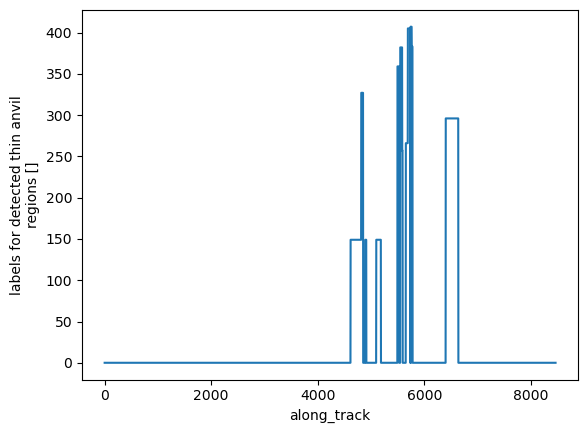

In [7]:
overpass_dt.thin_anvil_label.plot()

In [8]:
np.unique(overpass_dt.thin_anvil_label)

array([  0, 149, 257, 266, 296, 327, 359, 382, 383, 405, 407], dtype=int32)

In [9]:
def select_anvil(ds, anvil):
    ds = ds.sel(anvil=anvil)
    ds = ds.isel(thick_anvil_step=ds.thick_anvil_step_anvil_index==anvil)
    ds = ds.isel(thin_anvil_step=ds.thin_anvil_step_anvil_index==anvil)
    ds = ds.isel(core=ds.core_anvil_index==anvil)
    ds = ds.isel(core_step=np.isin(ds.core_step_core_index, ds.core))
    return ds

def get_overpass_attrs(
    overpass_slice: xr.Dataset, stats_ds: xr.Dataset, anvil_id: int
) -> dict:
    if anvil_id not in stats_ds.anvil:
        raise ValueError(f'Anvil {anvil_id} not found in stats dataset')

    anvil_ds = select_anvil(stats_ds, anvil_id)

    anvil_is_valid = anvil_ds.thin_anvil_is_valid.item()
    mean_overpass_time = overpass_slice.time.mean().values
    time_from_init = mean_overpass_time - anvil_ds.thick_anvil_start_t.values
    prop_from_init = time_from_init / anvil_ds.thick_anvil_lifetime.values
    anvil_core_count = anvil_ds.anvil_core_count.item()
    anvil_core_intensity = anvil_ds.core_max_cooling_rate.max().item()
    anvil_max_area = anvil_ds.thick_anvil_max_area.item()
    anvil_min_bt = anvil_ds.thick_anvil_bt_min.item()
    anvil_lifetime_stage = ["growing", "maturing", "dissipating"][
        0 if mean_overpass_time < anvil_ds.thick_anvil_min_bt_t else 1 if mean_overpass_time < anvil_ds.thick_anvil_max_area_t else 2
    ]

    nearest_overpass_step = np.abs(anvil_ds.thick_anvil_step_t - mean_overpass_time).idxmin().item()

    from pyproj import Geod

    g = Geod(ellps='GRS80')

    min_overpass_distance = g.inv(
        np.repeat(anvil_ds.thick_anvil_step_lon.sel(thick_anvil_step=nearest_overpass_step).item(), overpass_slice.along_track.size), 
        np.repeat(anvil_ds.thick_anvil_step_lat.sel(thick_anvil_step=nearest_overpass_step).item(), overpass_slice.along_track.size), 
        overpass_slice.longitude.values, 
        overpass_slice.latitude.values
    )[-1].min()/1e3

    return dict(
        anvil_id=anvil_id, 
        anvil_is_valid=str(anvil_is_valid), 
        mean_overpass_time=str(mean_overpass_time),
        time_from_init=int(time_from_init)/1e9, 
        prop_from_init=prop_from_init, 
        anvil_core_count=anvil_core_count, 
        anvil_core_intensity=anvil_core_intensity, 
        anvil_max_area=anvil_max_area, 
        anvil_min_bt=anvil_min_bt, 
        anvil_lifetime_stage=anvil_lifetime_stage, 
        min_overpass_distance=min_overpass_distance, 
    )

def output_colocated_ec_slices(ec_ds_coloc, colocated_anvil_labels, stats_ds, stats_file): #, save_path, product, earthcare_file, stats_file, mask_file):
    for anvil_id in np.unique(colocated_anvil_labels):
        if anvil_id > 0:
            wh_overpass = np.where(colocated_anvil_labels==anvil_id)[0]
            overpass_slice = ec_ds_coloc.isel(along_track = slice(
                np.maximum(0, wh_overpass.min()-100),
                np.minimum(colocated_anvil_labels.size, wh_overpass.max()+100),
            ))
            if len(overpass_slice.along_track) > 0:
                try:
                    for k, v in get_overpass_attrs(overpass_slice, stats_ds, anvil_id).items():
                        overpass_slice[k] = v
                    overpass_slice.attrs["stats_file"] = stats_file.name
                    overpass_slice["/dcc_properties"] = select_anvil(stats_ds, overpass_slice.anvil_id)
                except ValueError:
                    pass
                else:
                    yield overpass_slice
                    # mean_time = datetime.fromisoformat(overpass_slice.mean_overpass_time).strftime("%Y%m%d%H%M%S")
                    # save_name = f'{product}_o{earthcare_file.stem.split("_")[-1]}_t{mean_time}_a{anvil_id}.nc'
                    # print(save_name)
                    # del overpass_slice.time.attrs["units"]
                    # overpass_slice.to_netcdf(save_path / save_name, mode="a")
                    

In [10]:
slice_dts = [dt for dt in output_colocated_ec_slices(
    overpass_dt, overpass_dt.thin_anvil_label, stats_ds, stats_file
)]

In [11]:
slice_dts[0]

<xarray.DataTree>
Group: /
│   Dimensions:                (along_track: 769, height: 200)
│   Coordinates:
│       time                   (along_track) datetime64[ns] 6kB 2024-08-10T00:33:...
│       latitude               (along_track) float64 6kB 2.596 2.605 ... 9.686 9.694
│       longitude              (along_track) float64 6kB 21.92 21.92 ... 20.59 20.59
│     * height                 (height) float64 2kB 1.995e+04 1.985e+04 ... 50.0
│   Dimensions without coordinates: along_track
│   Data variables: (12/14)
│       core_label             (along_track) int32 3kB ...
│       thick_anvil_label      (along_track) int32 3kB ...
│       thin_anvil_label       (along_track) int32 3kB 0 0 0 0 0 0 0 ... 0 0 0 0 0 0
│       anvil_id               int32 4B 149
│       anvil_is_valid         <U5 20B 'False'
│       mean_overpass_time     <U29 116B '2024-08-10T00:34:07.738601996'
│       ...                     ...
│       anvil_core_count       int64 8B 266
│       anvil_core_intensity   float64 8B 3.279
│       anvil_max_area         float64 8B 5.915e+05
│       anvil_min_bt           float64 8B 180.9
│       anvil_lifetime_stage   <U7 28B 'growing'
│       min_overpass_distance  float64 8B 166.6
│   Attributes:
│       granules:              01136H 01137A 01137B
│       track_mask_filenames:  detected_dccs_MSG_S20240810_000000_E20240811_00000...
│       stats_file:            dcc_statistics_orcestra_S20240810_000000_E20241001...
├── Group: /CPR_CD__2A
│       Dimensions:                                                (along_track: 769,
│                                                                   height: 200)
│       Coordinates:
│           time                                                   (along_track) datetime64[ns] 6kB ...
│           latitude                                               (along_track) float64 6kB ...
│           longitude                                              (along_track) float64 6kB ...
│       Dimensions without coordinates: along_track
│       Data variables:
│           quality_status                                         (along_track, height) float32 615kB ...
│           doppler_velocity_and_spectrum_width_integrated_error   (along_track, height) float32 615kB ...
│           doppler_velocity_and_spectrum_width_integrated_status  (along_track, height) float32 615kB ...
│           doppler_velocity_best_estimate                         (along_track, height) float32 615kB ...
│           sedimentation_velocity_best_estimate                   (along_track, height) float32 615kB ...
│           sedimentation_velocity_best_estimate_error             (along_track, height) float32 615kB ...
│           sedimentation_velocity_best_estimate_status            (along_track, height) float32 615kB ...
│       Attributes:
│           File_Name:         ECA_EXBA_CPR_CD__2A_20240810T001450Z_20250904T193109Z_...
│           File_Description:  
│           Notes:             Test Notes
│           Mission:           EarthCARE
│           File_Class:        EXBA
│           File_Type:         CPR_CD__2A
│           File_Version:      0001
├── Group: /CPR_FMR_2A
│       Dimensions:                     (along_track: 769, height: 200)
│       Coordinates:
│           time                        (along_track) datetime64[ns] 6kB ...
│           latitude                    (along_track) float64 6kB ...
│           longitude                   (along_track) float64 6kB ...
│       Dimensions without coordinates: along_track
│       Data variables:
│           surface_elevation           (along_track) float32 3kB ...
│           land_flag                   (along_track) float32 3kB ...
│           quality_status              (along_track, height) float32 615kB ...
│           reflectivity_error          (along_track, height) float32 615kB ...
│           reflectivity_corrected      (along_track, height) float32 615kB ...
│           multiple_scattering_status  (along_track, height) float64 1MB ...
│           

In [12]:
slice_save_path = pathlib.Path("/work/scratch-nopw2/wkjones/ec_anvil_overpasses/")
slice_save_path.mkdir(exist_ok=True)

In [13]:
for k, v in slice_dts[0].data_vars.items():
    print(len(v.dims))

1
1
1
0
0
0
0
0
0
0
0
0
0
0


In [14]:
{
    k:v.item() for k, v in slice_dts[0].data_vars.items() if len(v.dims) == 0
}

{'anvil_id': 149,
 'anvil_is_valid': 'False',
 'mean_overpass_time': '2024-08-10T00:34:07.738601996',
 'time_from_init': 1285.440601996,
 'prop_from_init': 0.00755699437524349,
 'anvil_core_count': 266,
 'anvil_core_intensity': 3.278954029083252,
 'anvil_max_area': 591520.25,
 'anvil_min_bt': 180.8583984375,
 'anvil_lifetime_stage': 'growing',
 'min_overpass_distance': 166.56647936975918}

In [15]:
overpass_attrs = []

for overpass_file in overpass_files:
    with xr.open_datatree(overpass_file) as overpass_dt:
        for overpass_slice in output_colocated_ec_slices(
            overpass_dt, overpass_dt.thin_anvil_label, stats_ds, stats_file
        ):
            mean_time = datetime.fromisoformat(overpass_slice.mean_overpass_time.item()).strftime("%Y%m%d%H%M%S")
            save_name = f'earthcare_anvil_overpass_t{mean_time}_a{overpass_slice.anvil_id.item():06d}.nc'

            overpass_attr_dict = {
                k:v.item() for k, v in overpass_slice.data_vars.items() if len(v.dims) == 0
            }
            overpass_attr_dict["save_name"] = save_name
            overpass_attrs.append(overpass_attr_dict)
        
            # comp = dict(zlib=True, complevel=5, shuffle=True)
            # for var in overpass_slice.data_vars:
            #     overpass_slice[var].encoding.update(comp)
            # for dt in overpass_slice.descendants:
            #     for var in dt.data_vars:
            #         dt[var].encoding.update(comp)
        
            print(save_name)
            overpass_slice.to_netcdf(slice_save_path/save_name)

earthcare_anvil_overpass_t20240810003407_a000149.nc
earthcare_anvil_overpass_t20240810003546_a000257.nc
earthcare_anvil_overpass_t20240810003758_a000296.nc
earthcare_anvil_overpass_t20240810003534_a000359.nc
earthcare_anvil_overpass_t20240810003603_a000405.nc
earthcare_anvil_overpass_t20240810003609_a000407.nc
earthcare_anvil_overpass_t20240810015639_a000072.nc
earthcare_anvil_overpass_t20240810050217_a000024.nc
earthcare_anvil_overpass_t20240810064303_a000112.nc
earthcare_anvil_overpass_t20240810064444_a000186.nc
earthcare_anvil_overpass_t20240810064536_a000450.nc
earthcare_anvil_overpass_t20240810064514_a000487.nc
earthcare_anvil_overpass_t20240810090327_a000101.nc
earthcare_anvil_overpass_t20240810103348_a000101.nc
earthcare_anvil_overpass_t20240810121547_a000499.nc
earthcare_anvil_overpass_t20240810120217_a000606.nc
earthcare_anvil_overpass_t20240810120420_a000766.nc
earthcare_anvil_overpass_t20240810120510_a000891.nc
earthcare_anvil_overpass_t20240810120551_a000939.nc
earthcare_an

In [16]:
pd.DataFrame(overpass_attrs)

,anvil_id,anvil_is_valid,mean_overpass_time,time_from_init,prop_from_init,anvil_core_count,anvil_core_intensity,anvil_max_area,anvil_min_bt,anvil_lifetime_stage,min_overpass_distance,save_name
0,149,False,2024-08-10T00:34:07.738601996,1285.440602,0.007557,266,3.278954,591520.250000,180.858398,growing,166.566479,earthcare_anvil_overpass_t20240810003407_a0001...
1,257,False,2024-08-10T00:35:46.096949160,1383.798949,0.023296,1,0.632389,39848.765625,203.573898,growing,291.395761,earthcare_anvil_overpass_t20240810003546_a0002...
2,296,False,2024-08-10T00:37:58.613201748,1516.315202,0.013060,52,2.323281,94521.179688,185.596848,growing,159.536297,earthcare_anvil_overpass_t20240810003758_a0002...
3,359,False,2024-08-10T00:35:34.954002408,1372.656002,0.084731,2,0.929182,9513.859375,192.940323,maturing,14.245211,earthcare_anvil_overpass_t20240810003534_a0003...
4,405,False,2024-08-10T00:36:03.811584036,1401.513584,0.091601,1,0.933011,2711.987793,206.313095,growing,8.165477,earthcare_anvil_overpass_t20240810003603_a0004...
...,...,...,...,...,...,...,...,...,...,...,...,...
768,61504,False,2024-09-15T10:18:43.421790824,10260.931791,0.223548,2,0.790657,73705.195312,224.305069,growing,112.732957,earthcare_anvil_overpass_t20240915101843_a0615...
769,61595,False,2024-09-15T11:57:48.426580796,9906.504581,0.189779,30,1.848756,71228.812500,184.850418,growing,36.459172,earthcare_anvil_overpass_t20240915115748_a0615...
770,61735,False,2024-09-15T11:58:01.926716020,4519.237716,0.200858,2,2.444542,6627.517090,189.779144,growing,69.416485,earthcare_anvil_overpass_t20240915115801_a0617...
771,61811,False,2024-09-15T11:56:30.424876640,-971.862123,-0.039995,1,1.704699,12615.585938,191.706818,growing,52.240128,earthcare_anvil_overpass_t20240915115630_a0618...


In [65]:
slice_dts[-1]

<xarray.DataTree>
Group: /
│   Dimensions:                (along_track: 221, height: 200)
│   Coordinates:
│       time                   (along_track) datetime64[ns] 2kB 2024-08-10T00:35:...
│       latitude               (along_track) float64 2kB 13.01 13.01 ... 15.03 15.04
│       longitude              (along_track) float64 2kB 19.96 19.95 ... 19.56 19.56
│     * height                 (height) float64 2kB 1.995e+04 1.985e+04 ... 50.0
│   Dimensions without coordinates: along_track
│   Data variables: (12/14)
│       core_label             (along_track) int32 884B ...
│       thick_anvil_label      (along_track) int32 884B ...
│       thin_anvil_label       (along_track) int32 884B 0 0 0 0 0 0 ... 0 0 0 0 0 0
│       anvil_id               int32 4B 407
│       anvil_is_valid         <U5 20B 'False'
│       mean_overpass_time     <U29 116B '2024-08-10T00:36:09.454669352'
│       ...                     ...
│       anvil_core_count       int64 8B 1
│       anvil_core_intensity   float64 8B 0.8791
│       anvil_max_area         float64 8B 2.764e+03
│       anvil_min_bt           float64 8B 205.0
│       anvil_lifetime_stage   <U7 28B 'growing'
│       min_overpass_distance  float64 8B 15.88
│   Attributes:
│       granules:              01136H 01137A 01137B
│       track_mask_filenames:  detected_dccs_MSG_S20240810_000000_E20240811_00000...
│       stats_file:            dcc_statistics_orcestra_S20240810_000000_E20241001...
├── Group: /CPR_CD__2A
│       Dimensions:                                                (along_track: 221,
│                                                                   height: 200)
│       Coordinates:
│           time                                                   (along_track) datetime64[ns] 2kB ...
│           latitude                                               (along_track) float64 2kB ...
│           longitude                                              (along_track) float64 2kB ...
│       Dimensions without coordinates: along_track
│       Data variables:
│           quality_status                                         (along_track, height) float32 177kB ...
│           doppler_velocity_and_spectrum_width_integrated_error   (along_track, height) float32 177kB ...
│           doppler_velocity_and_spectrum_width_integrated_status  (along_track, height) float32 177kB ...
│           doppler_velocity_best_estimate                         (along_track, height) float32 177kB ...
│           sedimentation_velocity_best_estimate                   (along_track, height) float32 177kB ...
│           sedimentation_velocity_best_estimate_error             (along_track, height) float32 177kB ...
│           sedimentation_velocity_best_estimate_status            (along_track, height) float32 177kB ...
│       Attributes:
│           File_Name:         ECA_EXBA_CPR_CD__2A_20240810T001450Z_20250904T193109Z_...
│           File_Description:  
│           Notes:             Test Notes
│           Mission:           EarthCARE
│           File_Class:        EXBA
│           File_Type:         CPR_CD__2A
│           File_Version:      0001
├── Group: /CPR_FMR_2A
│       Dimensions:                     (along_track: 221, height: 200)
│       Coordinates:
│           time                        (along_track) datetime64[ns] 2kB ...
│           latitude                    (along_track) float64 2kB ...
│           longitude                   (along_track) float64 2kB ...
│       Dimensions without coordinates: along_track
│       Data variables:
│           surface_elevation           (along_track) float32 884B ...
│           land_flag                   (along_track) float32 884B ...
│           quality_status              (along_track, height) float32 177kB ...
│           reflectivity_error          (along_track, height) float32 177kB ...
│           reflectivity_corrected      (along_track, height) float32 177kB ...
│           multiple_scattering_status  (along_track, height) float64 354kB ...
│       